# Homework: Gradient Descent for Linear Regression

In this assignment, you will fit a straight line using **mean squared error (MSE)** and gradient descent. You will implement both an analytical gradient and a finite-difference numerical gradient, then compare them.

Think of the loss as a landscape: gradient descent is like hiking downhill in fog, using the local slope to choose a direction. This makes it practical to optimize model parameters even when the best values are not obvious by inspection.

The model has two parameters:

$$\hat{y} = wx + b$$

where $w$ is the slope and $b$ is the intercept.

## Learning goals

- Explain why gradient descent minimizes a loss by moving opposite the gradient.
- Derive and implement the MSE gradients for $w$ and $b$.
- Estimate gradients with centered finite differences.
- Train a model and compare the learned parameters and loss.

## 1. Understand the objective

For $n$ observations, define the mean squared error as

$$L(w,b) = \frac{1}{n}\sum_{i=1}^{n}(wx_i+b-y_i)^2.$$

The gradient points in the direction of steepest increase. Gradient descent updates each parameter in the opposite direction:

$$w \leftarrow w - \alpha\frac{\partial L}{\partial w}, \qquad b \leftarrow b - \alpha\frac{\partial L}{\partial b}.$$

Here, $\alpha$ is the learning rate. A rate that is too large can cause the loss to diverge; one that is too small makes learning slow.

## 2. Set up the training data

We generate 10 points around the underlying relationship $y=2x+1$. The observed `X` values have measurement noise, and the observed `y` values have additional random noise. A fixed random seed makes the dataset repeatable. Your fitted parameters should be reasonably close to $w=2$ and $b=1$, but noise means they will not match exactly.

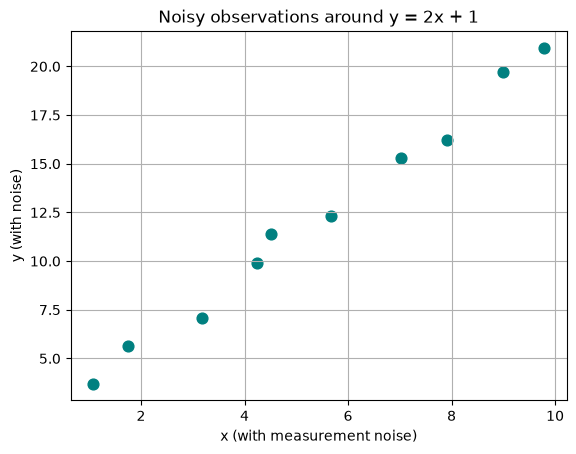

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
x_base = np.linspace(1.0, 10.0, 10)
X = x_base + rng.normal(0.0, 0.25, size=10)
y = 2.0 * x_base + 1.0 + rng.normal(0.0, 0.8, size=10)

plt.scatter(X, y, color="teal", s=60)
plt.xlabel("x (with measurement noise)")
plt.ylabel("y (with noise)")
plt.title("Noisy observations around y = 2x + 1")
plt.grid(True)
plt.show()

## 3. Implement the loss function

Complete `mse_loss`. It should return one number: the average of the squared prediction errors. Evaluate it at the generating line, $w=2$, $b=1$. Because the observations contain noise, this loss should be small but generally not zero.

In [ ]:
def mse_loss(w, b, X, y):
    # TODO: Predict with w * X + b, compute squared errors, and return their mean.
    pass

print("Loss at the true parameters:", mse_loss(2.0, 1.0, X, y))

## 4. Derive and implement the analytical gradient

Let $e_i = wx_i+b-y_i$. Use the chain rule to fill in the derivatives:

$$\frac{\partial L}{\partial w}=\frac{2}{n}\sum_i e_i x_i, \qquad \frac{\partial L}{\partial b}=\frac{2}{n}\sum_i e_i.$$

Implement `analytical_gradient`, then inspect the gradient at the initial point. What does its sign suggest about how $w$ and $b$ should change?

In [ ]:
def analytical_gradient(w, b, X, y):
    # TODO: Compute residuals and return (dL_dw, dL_db) for mean squared error.
    pass

print("Initial analytical gradient:", analytical_gradient(0.0, 0.0, X, y))

## 5. Estimate the gradient numerically

For a small $\epsilon$, centered finite differences estimate the derivative by comparing losses on either side of the current parameter:

$$\frac{\partial L}{\partial w}\approx\frac{L(w+\epsilon,b)-L(w-\epsilon,b)}{2\epsilon}.$$

Complete both components in `numerical_gradient`. Then compare this result with your analytical gradient at $w=0$, $b=0$. They should be very close.

**Automatic differentiation (conceptual extension):** Libraries such as PyTorch and JAX record differentiable operations and apply the chain rule automatically. It provides derivatives of the implemented computation, rather than estimating them with small perturbations. In real neural-network training, autodiff is usually preferred; finite differences remain handy for checking a gradient on a small example.

In [ ]:
def numerical_gradient(w, b, X, y, epsilon=1e-5):
    # TODO: Approximate dL/dw and dL/db with centered finite differences.
    pass

print("Numerical gradient:", numerical_gradient(0.0, 0.0, X, y))
print("Analytical gradient:", analytical_gradient(0.0, 0.0, X, y))

## 6. Train with analytical gradients

Complete the loop: on each epoch, calculate the current gradient, update both parameters, and record the loss. Use the provided learning rate and 1,000 epochs. Print the learned parameters and plot loss over time.

Try to explain why these updates move downhill even though the gradient itself points uphill.

In [ ]:
w = 0.0
b = 0.0
learning_rate = 0.01
epochs = 1000
loss_history = []

for epoch in range(epochs):
    # TODO: Get gradients from analytical_gradient and update w and b.
    # TODO: Append the current MSE to loss_history.
    pass

print(f"Learned w: {w:.4f}")
print(f"Learned b: {b:.4f}")
print(f"Final MSE: {mse_loss(w, b, X, y):.8f}")

plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Training loss")
plt.grid(True)
plt.show()

## 7. Train using numerical gradients

Run gradient descent again using the numerical gradient function. Start over from $w=0$, $b=0$, and compare the result and loss with the analytical-gradient run. Finite differences are flexible, but require extra loss evaluations and a suitable choice of $\epsilon$.

In [ ]:
w_num = 0.0
b_num = 0.0
numerical_losses = []

for epoch in range(epochs):
    # TODO: Get gradients from numerical_gradient and update w_num and b_num.
    pass
    # TODO: Append the current MSE to numerical_losses.

print(f"Numerical-gradient w: {w_num:.4f}")
print(f"Numerical-gradient b: {b_num:.4f}")
print(f"Final MSE: {mse_loss(w_num, b_num, X, y):.8f}")

plt.plot(numerical_losses)
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Training loss with numerical gradient")
plt.grid(True)
plt.show()

## 8. Explore the learning rate

A learning rate controls the size of each parameter update. Compare `0.001`, `0.01`, and `0.5` over up to 100 updates. Record the MSE after each update in a separate history for each rate, then plot all histories together with a logarithmic y-axis. If the loss exceeds `1e12` or becomes non-finite, stop that run and report that it diverged. Which rate makes steady progress? What does the unstable curve look like?

In [ ]:
loss_limit = 1e12
rate_histories = {}

for rate in [0.001, 0.01, 0.5]:
    trial_w = 0.0
    trial_b = 0.0
    rate_losses = []

    for epoch in range(100):
        # TODO: Compute analytical gradients and update trial_w and trial_b.
        pass

        # TODO: Compute the current MSE. If it exceeds loss_limit or is not
        # finite, report divergence and stop this rate's loop.
        # Otherwise append the MSE to rate_losses.
        pass

    rate_histories[rate] = rate_losses
    print(f"learning_rate={rate}: final recorded MSE={rate_losses[-1] if rate_losses else float('nan'):.6g}")

plt.figure(figsize=(8, 5))
for rate, losses in rate_histories.items():
    plt.semilogy(range(1, len(losses) + 1), losses, label=f"learning rate={rate}")
plt.axhline(loss_limit, color="gray", linestyle="--", linewidth=1, label="divergence limit")
plt.xlabel("Epoch")
plt.ylabel("MSE (log scale)")
plt.title("Effect of learning rate on training loss")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()